In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import pingouin as pg
import numpy as np

**Loading of data**


In [25]:
# Replace with our file path
df = pd.read_csv("ai_grading_final.csv")

# Required columns:
required_columns = [
    "answer_key_id",
    "true_mistakes",
    "prompt_type",
    "ai_estimated_mistakes"
]
# Dependent variable: AI grading error
df["ai_error"] = df["ai_estimated_mistakes"] - df["true_mistakes"]
df["Absolute_error"] = abs(df["ai_estimated_mistakes"]-df["true_mistakes"])
df["true_mistakes"] = df["true_mistakes"].astype("category")
df["prompt_type"] = df["prompt_type"].astype("category")

**Grouping of data**

In [ ]:
matrix = df.groupby(["true_mistakes", "prompt_type"])["ai_error"].apply(np.array).unstack("prompt_type")
#matrix.head()
fig, axes = plt.subplots(len(matrix.index), len(matrix.columns), figsize=(15, 20), sharey=True)

for i, true_mistakes in enumerate(matrix.index):
    for j, prompt_type in enumerate(matrix.columns):
        ax = axes[i, j]
        ax.hist(matrix.loc[true_mistakes, prompt_type],bins=np.arange(-2,8,1))
        if i == 0:
            ax.set_title(prompt_type, fontsize=8)
        if j == 0:
            ax.set_ylabel(f"mistakes={true_mistakes}", fontsize=8)

plt.suptitle("AI Error by True Mistakes and Prompt Type")
plt.tight_layout()
plt.show()

**2-way Mixed ANOVA**

Assumptions: Homogeneity of variance, Independence of observations, Normally-distributed dependent variable 


ANOVA SUMMARY

Source             SS    DF1    DF2      MS       F    p_unc    p_GG_corr    np2      eps    sphericity    W_spher    p_spher
-------------  ------  -----  -----  ------  ------  -------  -----------  -----  -------  ------------  ---------  ---------
true_mistakes  71.954      7    295  10.279  16.753    0.000      nan      0.284  nan           nan        nan        nan
prompt_type    21.283      4   1180   5.321  10.031    0.000        0.000  0.033    0.724         0.000      0.534      0.000
Interaction    22.048     28   1180   0.787   1.485    0.050      nan      0.034  nan           nan        nan        nan



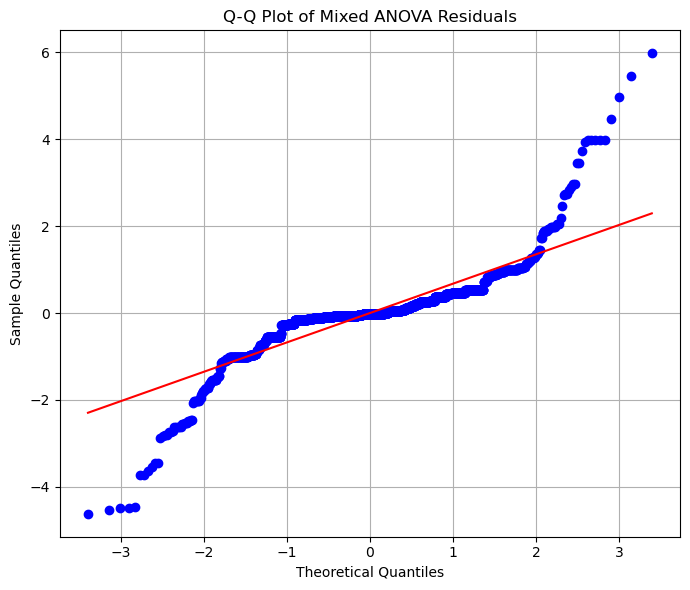

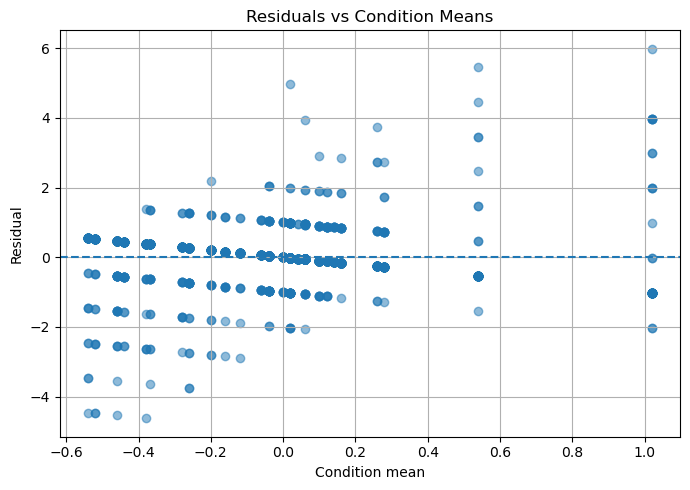

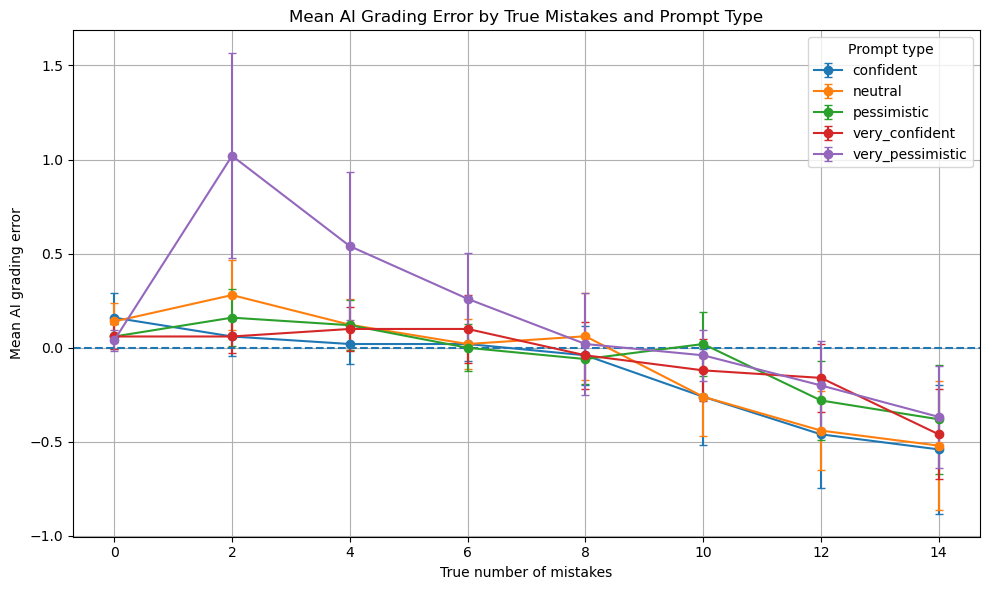

In [26]:
mixed_anova = pg.mixed_anova(
    data=df,
    dv="ai_error",
    within="prompt_type",
    between="true_mistakes",
    subject="answer_key_id"
)

pg.print_table(mixed_anova)

# 10. Q-Q plot of residual-like centered scores

df["cell_mean"] = df.groupby(
    ["true_mistakes", "prompt_type"],
    observed=False
)["ai_error"].transform("mean")

df["anova_residual"] = df["ai_error"] - df["cell_mean"]

plt.figure(figsize=(7, 6))
stats.probplot(df["anova_residual"], dist="norm", plot=plt)
plt.title("Q-Q Plot of Mixed ANOVA Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True)
plt.tight_layout()
plt.show()

# Residuals vs condition means
#How far is this specific observation from the average result in the same condition? 
# One specific combination of true error level and prompt type.
#Condition means is the average value for each experimental condition.

plt.figure(figsize=(7, 5))
plt.scatter(df["cell_mean"], df["anova_residual"], alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Condition Means")
plt.xlabel("Condition mean")
plt.ylabel("Residual")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot mean AI error by true mistakes and prompt

summary = (
    df.groupby(["true_mistakes", "prompt_type"], observed=False)
    .agg(
        mean_ai_error=("ai_error", "mean"),
        sd_ai_error=("ai_error", "std"),
        n=("ai_error", "count")
    )
    .reset_index()
)

summary["se_ai_error"] = summary["sd_ai_error"] / np.sqrt(summary["n"])
summary["ci95"] = 1.96 * summary["se_ai_error"]
summary["true_mistakes_numeric"] = summary["true_mistakes"].astype(int)

plt.figure(figsize=(10, 6))

for prompt in summary["prompt_type"].unique():
    subset = summary[summary["prompt_type"] == prompt]

    plt.errorbar(
        subset["true_mistakes_numeric"],
        subset["mean_ai_error"],
        yerr=subset["ci95"],
        marker="o",
        capsize=3,
        label=str(prompt)
    )

plt.axhline(0, linestyle="--")
plt.title("Mean AI Grading Error by True Mistakes and Prompt Type")
plt.xlabel("True number of mistakes")
plt.ylabel("Mean AI grading error")
plt.legend(title="Prompt type")
plt.grid(True)
plt.tight_layout()
plt.show()


In [27]:
# Post-hoc tests between prompts
# Since prompt_type is a repeated-measures factor, comparisons between prompts should be paired t-tests with holm-correction.

posthoc_prompts = pg.pairwise_tests(
    data=df,
    dv="ai_error",
    within="prompt_type",
    subject="answer_key_id",
    parametric=True,
    padjust="holm",
    effsize="hedges"
)

print(posthoc_prompts)


      Contrast               A                 B  Paired  Parametric  \
0  prompt_type       confident           neutral    True        True   
1  prompt_type       confident       pessimistic    True        True   
2  prompt_type       confident    very_confident    True        True   
3  prompt_type       confident  very_pessimistic    True        True   
4  prompt_type         neutral       pessimistic    True        True   
5  prompt_type         neutral    very_confident    True        True   
6  prompt_type         neutral  very_pessimistic    True        True   
7  prompt_type     pessimistic    very_confident    True        True   
8  prompt_type     pessimistic  very_pessimistic    True        True   
9  prompt_type  very_confident  very_pessimistic    True        True   

          T    dof alternative     p_unc    p_corr p_adjust      BF10  \
0 -1.284328  302.0   two-sided  0.200011  0.800046     holm     0.145   
1 -2.213161  302.0   two-sided  0.027634  0.165804     holm  

**ABSOLUTE ERROR VERSION**


ANOVA SUMMARY

Source             SS    DF1    DF2     MS      F    p_unc    p_GG_corr    np2      eps    sphericity    W_spher    p_spher
-------------  ------  -----  -----  -----  -----  -------  -----------  -----  -------  ------------  ---------  ---------
true_mistakes   7.756      7    295  1.108  2.127    0.041      nan      0.048  nan           nan        nan        nan
prompt_type    12.640      4   1180  3.160  6.346    0.000        0.000  0.021    0.720         0.000      0.528      0.000
Interaction    25.120     28   1180  0.897  1.802    0.007      nan      0.041  nan           nan        nan        nan



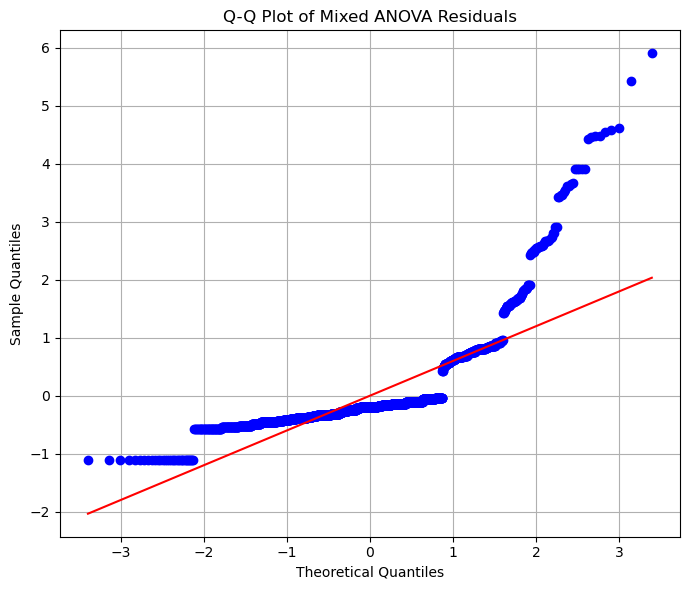

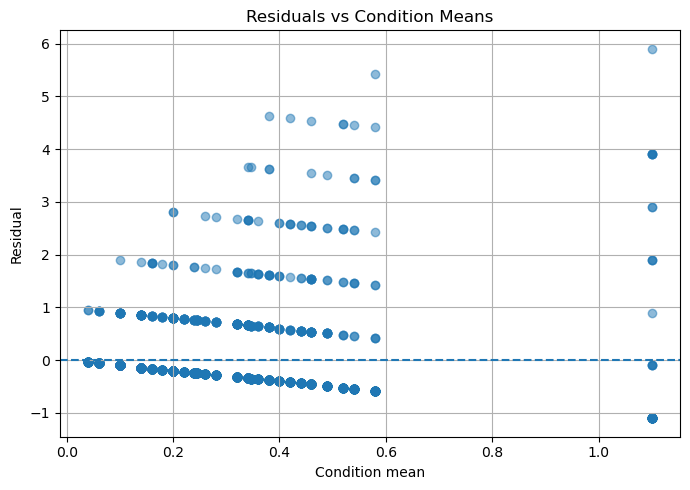

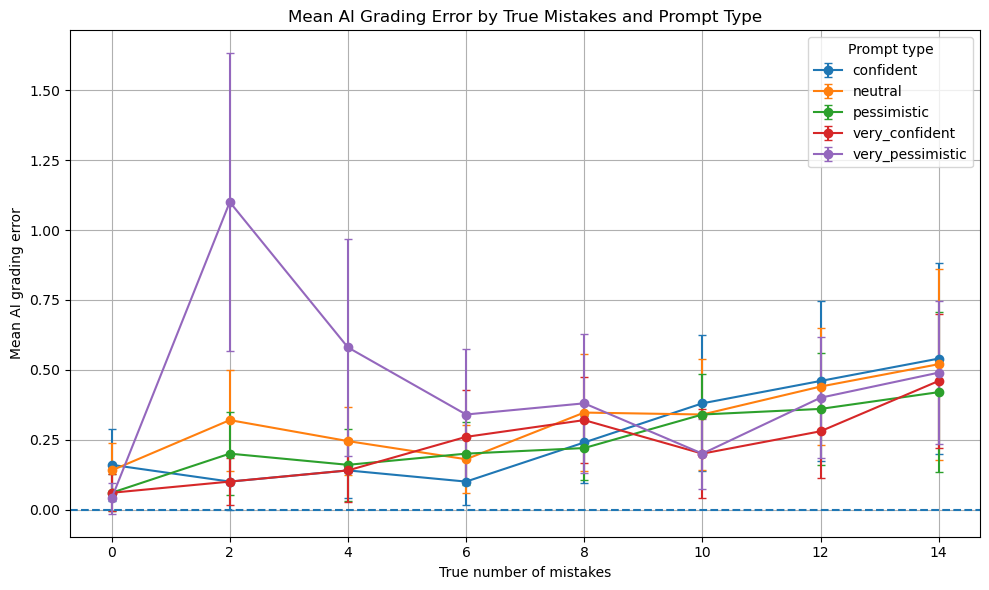

In [28]:
import pingouin as pg

mixed_anova = pg.mixed_anova(
    data=df,
    dv="Absolute_error",
    within="prompt_type",
    between="true_mistakes",
    subject="answer_key_id"
)

pg.print_table(mixed_anova)

# 10. Q-Q plot of residual-like centered scores

df["cell_mean"] = df.groupby(
    ["true_mistakes", "prompt_type"],
    observed=False
)["Absolute_error"].transform("mean")

df["anova_residual"] = df["Absolute_error"] - df["cell_mean"]

plt.figure(figsize=(7, 6))
stats.probplot(df["anova_residual"], dist="norm", plot=plt)
plt.title("Q-Q Plot of Mixed ANOVA Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True)
plt.tight_layout()
plt.show()

# Residuals vs condition means

plt.figure(figsize=(7, 5))
plt.scatter(df["cell_mean"], df["anova_residual"], alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Condition Means")
plt.xlabel("Condition mean")
plt.ylabel("Residual")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot mean AI error by true mistakes and prompt

summary = (
    df.groupby(["true_mistakes", "prompt_type"], observed=False)
    .agg(
        mean_ai_error=("Absolute_error", "mean"),
        sd_ai_error=("Absolute_error", "std"),
        n=("Absolute_error", "count")
    )
    .reset_index()
)

summary["se_ai_error"] = summary["sd_ai_error"] / np.sqrt(summary["n"])
summary["ci95"] = 1.96 * summary["se_ai_error"]
summary["true_mistakes_numeric"] = summary["true_mistakes"].astype(int)

plt.figure(figsize=(10, 6))

for prompt in summary["prompt_type"].unique():
    subset = summary[summary["prompt_type"] == prompt]

    plt.errorbar(
        subset["true_mistakes_numeric"],
        subset["mean_ai_error"],
        yerr=subset["ci95"],
        marker="o",
        capsize=3,
        label=str(prompt)
    )

plt.axhline(0, linestyle="--")
plt.title("Mean AI Grading Error by True Mistakes and Prompt Type")
plt.xlabel("True number of mistakes")
plt.ylabel("Mean AI grading error")
plt.legend(title="Prompt type")
plt.grid(True)
plt.tight_layout()
plt.show()

In [29]:
# Post-hoc tests between prompts
# Since prompt_type is a repeated-measures factor, comparisons between prompts should be paired t-tests with holm-correction.

posthoc_prompts = pg.pairwise_tests(
    data=df,
    dv="Absolute_error",
    within="prompt_type",
    subject="answer_key_id",
    parametric=True,
    padjust="holm",
    effsize="hedges"
)

print(posthoc_prompts)


      Contrast               A                 B  Paired  Parametric  \
0  prompt_type       confident           neutral    True        True   
1  prompt_type       confident       pessimistic    True        True   
2  prompt_type       confident    very_confident    True        True   
3  prompt_type       confident  very_pessimistic    True        True   
4  prompt_type         neutral       pessimistic    True        True   
5  prompt_type         neutral    very_confident    True        True   
6  prompt_type         neutral  very_pessimistic    True        True   
7  prompt_type     pessimistic    very_confident    True        True   
8  prompt_type     pessimistic  very_pessimistic    True        True   
9  prompt_type  very_confident  very_pessimistic    True        True   

          T    dof alternative     p_unc    p_corr p_adjust    BF10    hedges  
0 -1.376672  302.0   two-sided  0.169633  0.678533     holm   0.164 -0.102292  
1  0.086485  302.0   two-sided  0.931138  1.000